import datasets

In [25]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

load iris

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

explore iris

In [27]:
print(iris.data.shape)

(150, 4)


In [28]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [29]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [30]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [31]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
X = df.drop('target', axis='columns')
y = df.target

train-test

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

default estimator=10

In [34]:
model = RandomForestClassifier(n_estimators=10,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [35]:
score = model.score(X_test, y_test)
print("Accuracy with 10 trees:", score)

Accuracy with 10 trees: 1.0


default estimator=30

In [36]:
model = RandomForestClassifier(n_estimators=30,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=30, random_state=42)

In [37]:
score = model.score(X_test, y_test)
print("Accuracy with 30 trees:", score)

Accuracy with 30 trees: 1.0


default estimator=20

In [38]:
model = RandomForestClassifier(n_estimators=20,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [39]:
score = model.score(X_test, y_test)
print("Accuracy with 20 trees:", score)

Accuracy with 20 trees: 1.0


In [40]:
y_predict=model.predict(X_test)
y_predict

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

best score

In [41]:
best_score = 0
best_trees = 0

In [42]:
for tress in range(1,202):
  model=RandomForestClassifier(n_estimators=tress,random_state=42)
  model.fit(X_train, y_train)
  score = model.score(X_test, y_test)

In [43]:
if score > best_score:
        best_score = score
        best_trees = tress

print("Best Score:", best_score)
print("Best Number of Trees:", best_trees)

Best Score: 1.0
Best Number of Trees: 201


Confusion Matrix

In [44]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

Text(95.72222222222221, 0.5, 'Truth')

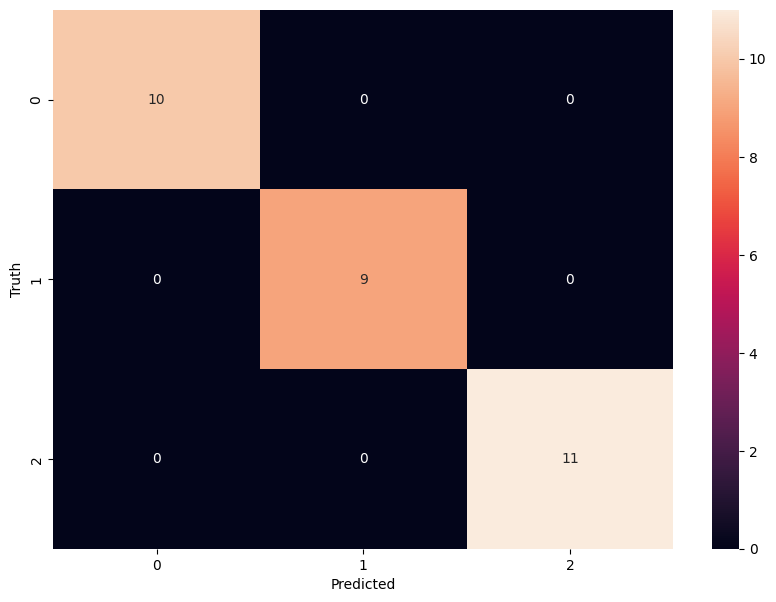

In [45]:
%matplotlib inline
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [46]:
import joblib

In [47]:
joblib.dump(model,'iris_random_forest_model.joblib')
print("Model Saved Successfully")

Model Saved Successfully
